# **AI Agent_Memory 관리**

**Memory**
- AI Agent가 이전 상태(state)나 대화 기록을 유지하고 재사용할 수 있도록 하는 기능
    - 유저와 AI 간의 대화를 저장하여 지속적인 맥락을 유지
    - 단순한 세션 메모리 뿐만 아니라, 외부 저장소를 활용하여 장기적인 상태를 저장
- 단기기억과 장기기억 정보를 제어하기 위한 로직을 넣을 수 있음.
    

## **1.환경준비**

### (1) 구글 드라이브

#### 1) 구글 드라이브 폴더 생성
* 새 폴더(LangGraph)를 생성하고
* 제공 받은 파일을 업로드

#### 2) 구글 드라이브 연결

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### (2) 라이브러리

#### 1) 필요한 라이브러리 설치

In [ ]:
!pip install langchain langgraph typing typing_extensions langchain-openai langchain_core langchain-community wikipedia -q

#### 2) 라이브러리 로딩

In [1]:
import pandas as pd
import numpy as np
import os
import openai

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

from typing import Annotated, Literal, TypedDict
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_core.tools import tool
from langgraph.graph import END, START, StateGraph, MessagesState, add_messages
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import ToolNode

c:\Users\USER\anaconda3\envs\aivle_pytorch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### (3) OpenAI API Key 확인

In [2]:
def load_api_keys(filepath="api_key.txt"):
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line and "=" in line:
                key, value = line.split("=", 1)
                os.environ[key.strip()] = value.strip()

path = '../'

# API 키 로드 및 환경변수 설정
load_api_keys(path + 'API_KEY.env')

⚠️ 아래 코드셀은, 실행해서 key가 제대로 보이는지 확인하고 삭제하세요.

In [3]:
print(os.environ['OPENAI_API_KEY'][:30])

sk-proj-NZCTfKEaIvmWyBt61dmY6A


## 2.기억력 없는 chatbot

### (1) State 정의

In [4]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

### (2) Node 정의

In [5]:
llm = ChatOpenAI(model="gpt-4.1-mini")  # 언어 모델을 gpt-4.1-mini로 설정

def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

### (3) 그래프 정의

In [6]:
# initiate a graph
builder = StateGraph(State)

# add a node
builder.add_node("chatbot", chatbot)

# connect nodes
builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

# compile the graph
graph = builder.compile()

* 그래프 시각화

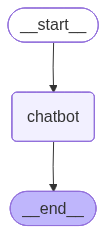

In [7]:
from IPython.display import Image, display

# 외부 서버를 호출하는 동안 대기시간 초과로 오류가 날 수 있습니다.
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

### (4) Graph 실행

* 실행1

In [59]:
for i in range(0, 52):
    print("{img:" + str(i) + "}")

{img:0}
{img:1}
{img:2}
{img:3}
{img:4}
{img:5}
{img:6}
{img:7}
{img:8}
{img:9}
{img:10}
{img:11}
{img:12}
{img:13}
{img:14}
{img:15}
{img:16}
{img:17}
{img:18}
{img:19}
{img:20}
{img:21}
{img:22}
{img:23}
{img:24}
{img:25}
{img:26}
{img:27}
{img:28}
{img:29}
{img:30}
{img:31}
{img:32}
{img:33}
{img:34}
{img:35}
{img:36}
{img:37}
{img:38}
{img:39}
{img:40}
{img:41}
{img:42}
{img:43}
{img:44}
{img:45}
{img:46}
{img:47}
{img:48}
{img:49}
{img:50}
{img:51}


In [ ]:
result = graph.invoke({"messages": [HumanMessage("안녕? 내 이름은 한기영이야.")]})
for message in result["messages"]:
    message.pretty_print()

* 실행2

In [9]:
result = graph.invoke({"messages": [HumanMessage("내 이름이 뭐라고?")]})
for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

내 이름이 뭐라고?
================================== Ai Message ==================================

아직 당신의 이름을 알지 못해요. 알려주시면 기억할 수 있어요!


## 3.Agent에 메모리 추가

**메모리 종류**
- MemorySaver : Short-term Memory
- SqliteSaver : Long-term Memory



### (1) 메모리 준비 : MemorySaver
**MemorySaver**
- Short-term Memory
- LangGraph에서 제공하는 체크포인트(Checkpoint) 저장소
- 그래프 실행 중 생성되는 상태(state)를 자동으로 저장하고 필요 시 복원할 수 있게 해주는 메모리 기반 저장소
- 특징

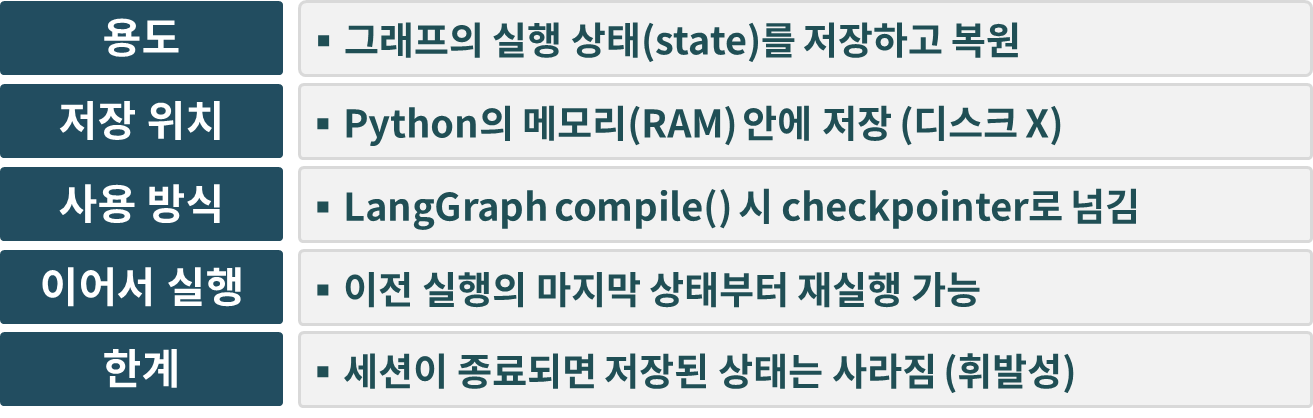   
  

In [10]:
# 체크포인터를 추가하여 그래프를 컴파일하면 메모리가 활성화됩니다.
from langgraph.checkpoint.memory import MemorySaver  # MemorySaver 모듈 가져오기
memory = MemorySaver()  # 메모리 기반 체크포인터 초기화

### (2) 이전 그래프 다시 컴파일

In [11]:
# 체크포인터와 함께 그래프 컴파일
agent_with_memory = builder.compile(checkpointer=memory)

### (3) 실행

* 스레드 지정

In [12]:
# 대화 흐름을 구분하기 위한 thread_id 설정
# 각 실행 흐름(예: 특정 대화 스레드)에 대해 고유한 thread_id를 키로 사용하고, 해당 키에 상태 데이터를 저장합니다.
thread_1 = {"configurable": {"thread_id": "1"}}

* 첫번째 메시지

In [13]:
messages = [HumanMessage(content="3과 4를 더하라")]
messages = agent_with_memory.invoke({"messages": messages}, thread_1)

for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

3과 4를 더하라
================================== Ai Message ==================================

3과 4를 더하면 7입니다.


* 두번째 메시지

In [14]:
messages = [HumanMessage(content="거기에 2를 곱하라.")]
messages = agent_with_memory.invoke({"messages": messages}, thread_1)

for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

3과 4를 더하라
================================== Ai Message ==================================

3과 4를 더하면 7입니다.
================================ Human Message =================================

거기에 2를 곱하라.
================================== Ai Message ==================================

7에 2를 곱하면 14입니다.


### (4) 새로운 대화

* 새로운 thread id 부여

In [15]:
# 새로운 스레드 id 부여
thread_2 = {"configurable": {"thread_id": "2"}}

messages = [HumanMessage(content="금리에 대한 정의를 알려줘.")]
messages = agent_with_memory.invoke({"messages": messages}, thread_2)

for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

금리에 대한 정의를 알려줘.
================================== Ai Message ==================================

금리(interest rate)는 돈을 빌리거나 빌려줄 때 일정 기간 동안 사용하는 대가로 지급하는 비율을 의미합니다. 즉, 돈을 빌린 사람이 원금에 대해 추가로 지불해야 하는 금액의 비율을 말하며, 보통 연 단위로 표시됩니다. 금리는 대출, 예금, 채권 등 다양한 금융 거래에서 중요한 역할을 합니다. 예를 들어, 대출 받을 때는 금리가 높으면 이자 부담이 커지고, 예금할 때는 금리가 높으면 받을 수 있는 이자가 많아집니다.


* 이전 thread id로 다시 대화

In [16]:
# 첫 번째 입력 메시지를 정의
messages = [HumanMessage(content="마지막으로 계산했던 숫자가 뭐였지?")]

# 그래프 실행 (MemorySaver가 활성화된 그래프 사용)
messages = agent_with_memory.invoke({"messages": messages},thread_1)
# 결과 메시지를 출력
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

3과 4를 더하라
================================== Ai Message ==================================

3과 4를 더하면 7입니다.
================================ Human Message =================================

거기에 2를 곱하라.
================================== Ai Message ==================================

7에 2를 곱하면 14입니다.
================================ Human Message =================================

마지막으로 계산했던 숫자가 뭐였지?
================================== Ai Message ==================================

마지막으로 계산했던 숫자는 14입니다.


### (5) 실습
* 2번 파일의 실습1에 메모리를 추가해 봅시다.

* LLM을 하나 생성하시오 (ChatOpenAI)
* 다음 도구 3개를 load_tools()를 사용하여 불러오고, ToolNode로 묶으시오
    * llm-math, wikipedia, serpapi
* GPT에게 도구 목록을 알려주기 위해 .bind_tools(tools)를 사용하시오
* 이를 위해 필요한 준비작업을 수행하시오.
    * serpapi api key를 받아 등록
    * 필요한 라이브러리 설치

In [17]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt.tool_node import ToolNode
from langchain.agents import load_tools
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
from typing import Literal, Annotated
from typing_extensions import TypedDict
from langchain_core.tools import tool

* 1) 메모리 준비 : MemorySaver

In [18]:
# 체크포인터를 추가하여 그래프를 컴파일하면 메모리가 활성화됩니다.
from langgraph.checkpoint.memory import MemorySaver  # MemorySaver 모듈 가져오기
memory = MemorySaver()  # 메모리 기반 체크포인터 초기화

* 2) Tool 준비하기

In [ ]:
!pip install google-search-results -q

In [33]:
from langchain.agents import load_tools
load_api_keys(path + 'API_KEY.env')

llm = ChatOpenAI(model="gpt-4.1-mini")
# tools = load_tools(["llm-math", "wikipedia", "serpapi"], llm=llm)
tools = load_tools(["llm-math", "wikipedia", "serpapi"], llm=llm)

# 체크포인터를 추가하여 그래프를 컴파일하면 메모리가 활성화됩니다.
from langgraph.checkpoint.memory import MemorySaver  # MemorySaver 모듈 가져오기
memory = MemorySaver()  # 메모리 기반 체크포인터 초기화


* 3) ToolNode 생성

In [34]:
tool_node = ToolNode(tools)
llm_with_tools = llm.bind_tools(tools)

* 4) 그래프 만들기

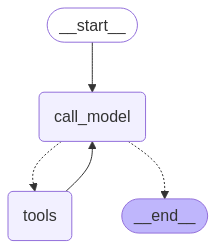

* State

In [35]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

* Node 와 분기 함수(conditional edge를 위한 함수)

In [36]:
# 모델 호출 함수 (GPT 호출)
def call_model(state: State):
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

def should_continue(state: State) -> Literal["tools", END]:
    messages = state["messages"]
    last_message = messages[-1]
    if last_message.tool_calls:
        return "tools"
    return END

* 그래프 구성

In [37]:
builder = StateGraph(State)

# 노드 추가
builder.add_node("call_model", call_model)
builder.add_node("tools", tool_node)

# 연결
builder.set_entry_point("call_model")
builder.add_conditional_edges("call_model", should_continue)
builder.add_edge("tools", "call_model") 

# 컴파일
graph = builder.compile(checkpointer=memory)

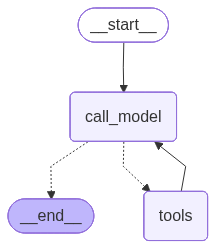

In [46]:
graph

* 5) 그래프 사용하기

* 첫번째 메시지

In [ ]:
thread_1 = {"configurable": {"thread_id": "1"}}
result = graph.invoke({
    "messages": [HumanMessage(content="위키피디아의 피타고라스의 정리를 설명해줘")]
}, thread_1)

# 출력
for message in result["messages"]:
    message.pretty_print()

* 두번째 메시지

In [ ]:
result = graph.invoke({
    "messages": [HumanMessage(content="내가 아까 물어본 공식 이름이 뭐야?")]
}, thread_1)

# 출력
for message in result["messages"]:
    message.pretty_print()

## 4.메모리 다루기

### (1) 메모리 조회

* thread id 1 에 저장된 메모리 스냅샷

In [42]:
agent_with_memory.get_state(thread_1).values

{'messages': [HumanMessage(content='3과 4를 더하라', additional_kwargs={}, response_metadata={}, id='1d373076-eca3-4d8a-92aa-f83853f7dfd2'),
  AIMessage(content='3과 4를 더하면 7입니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 15, 'total_tokens': 26, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_4c2851f862', 'id': 'chatcmpl-CV6ernVt3QMhiZ9qCl0MW8FxbO2Xe', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--f2c5cc55-0024-40be-b116-7201b0966b0d-0', usage_metadata={'input_tokens': 15, 'output_tokens': 11, 'total_tokens': 26, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}),
  HumanMessage(content='거기에 2를 곱하라.', additio

In [43]:
temp = agent_with_memory.get_state(thread_1).values
temp['messages'][-1].content

'마지막으로 계산했던 숫자는 14입니다.'

* thread id 2 에 저장된 메모리 스냅샷

In [44]:
agent_with_memory.get_state(thread_2).values

{'messages': [HumanMessage(content='금리에 대한 정의를 알려줘.', additional_kwargs={}, response_metadata={}, id='e2fcc1e6-b6cf-4d02-aebb-b179bec6668c'),
  AIMessage(content='금리(interest rate)는 돈을 빌리거나 빌려줄 때 일정 기간 동안 사용하는 대가로 지급하는 비율을 의미합니다. 즉, 돈을 빌린 사람이 원금에 대해 추가로 지불해야 하는 금액의 비율을 말하며, 보통 연 단위로 표시됩니다. 금리는 대출, 예금, 채권 등 다양한 금융 거래에서 중요한 역할을 합니다. 예를 들어, 대출 받을 때는 금리가 높으면 이자 부담이 커지고, 예금할 때는 금리가 높으면 받을 수 있는 이자가 많아집니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 127, 'prompt_tokens': 15, 'total_tokens': 142, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_4c2851f862', 'id': 'chatcmpl-CV6hpBPX9VIdD6QXImbc9BuWVTz9n', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--b824ffa9-5564-469e-8d17-afba016aede5-0', 

*  메모리 삭제
    * 공식적으로 제공되지 않음.
    * Thread id를 새로 시작하거나,
    * memory 인스턴스를 다시 지정

### (2) 최근 메시지 n개만 기억

기억할 메세지 개수 제한하기 --> 기록은 남지만 최근 n개의 프롬프트만 전송

* node 정의

In [45]:
def filter_messages(messages: list):
    # 최근 2개 메시지만 리턴하는 필터 함수 생성
    return messages[-2:]

def chatbot(state: State):
    messages = filter_messages(state["messages"])
    result = llm.invoke(messages)
    return {"messages": [result]}

* 그래프 정의

In [47]:
# initiate a graph
builder = StateGraph(State)

# add a node
builder.add_node("chatbot", chatbot)

# connect nodes
builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

# 체크포인터와 함께 그래프 컴파일
memory = MemorySaver()  # 메모리 기반 체크포인터 초기화
agent_with_memory = builder.compile(checkpointer=memory)

In [49]:
thread_10 = {"configurable": {"thread_id": "10"}}
messages = [HumanMessage(content="3과 4를 더하라")]
messages = agent_with_memory.invoke({"messages": messages}, thread_10)
messages['messages'][-1].pretty_print()

messages = [HumanMessage(content="내 이름은 한기영이야.")]
messages = agent_with_memory.invoke({"messages": messages}, thread_10)
messages['messages'][-1].pretty_print()

messages = [HumanMessage(content="오늘 날씨 어때?")]
messages = agent_with_memory.invoke({"messages": messages}, thread_10)
messages['messages'][-1].pretty_print()

messages = [HumanMessage(content="아까 계산했던 값이 얼마?")]
messages = agent_with_memory.invoke({"messages": messages}, thread_10)
messages['messages'][-1].pretty_print()

================================== Ai Message ==================================

3과 4를 더하면 7입니다.
================================== Ai Message ==================================

반갑습니다, 한기영님! 어떻게 도와드릴까요?
================================== Ai Message ==================================

죄송하지만 현재 위치 정보를 알 수 없어서 오늘 날씨를 정확히 알려드리기 어려워요. 계신 지역을 알려주시면 최신 날씨 정보를 찾아드릴게요! 어느 지역의 날씨가 궁금하세요?
================================== Ai Message ==================================

아까 계산했던 값에 대해 구체적으로 어떤 계산인지 알려주시면 도움이 될 것 같아요. 어떤 계산을 말씀하시는 건가요?


### (3) [추가] 메시지 요약

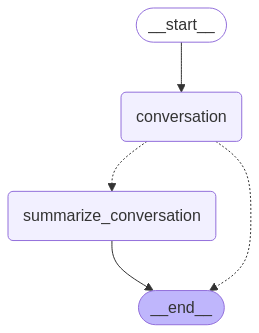

In [60]:
memory = MemorySaver()

#### 1) State
* MessagesState는 LangGraph가 기본 제공하는 메시지 기반 상태
* 여기에 **summary**라는 새로운 필드를 추가
* state 구조


    {
        "messages": [...],  # 전체 대화 기록
        "summary": "지금까지 요약된 내용"
    }

In [61]:
class State(MessagesState):
    summary: str

#### 2) 노드와 분기함수

* **대화 노드**

    * 기존 메시지 리스트로 GPT를 호출해서 응답을 받고,
    * 그 응답을 메시지 리스트에 **누적시킬 준비**를 해줌

In [62]:
def call_model(state: State):
    summary = state.get("summary", "")
    if summary:
        # 요약을 system prompt로 넣어 대화 맥락 유지
        system_message = f"이전 대화 요약: {summary}"
        messages = [SystemMessage(content=system_message)] + state["messages"]
    else:
        messages = state["messages"]

    response = llm.invoke(messages)
    return {"messages": [response]}

* **분기 조건**
    * 메시지가 6개 초과하면 **summarize_conversation** 노드로 분기
    * 그렇지 않으면 바로 **END**

In [63]:
def should_continue(state: State) -> Literal["summarize_conversation", END]:
    if len(state["messages"]) > 6:
        return "summarize_conversation"
    return END

* **요약 노드**
    * 지금까지 대화 내용으로 요약 생성
    * 메시지 너무 많아지지 않도록 앞쪽 메시지 삭제
    * 요약은 state["summary"]에 저장됨 (누적 요약 느낌)

In [64]:
from langchain_core.messages import RemoveMessage

def summarize_conversation(state: State):
    summary = state.get("summary", "")   # 이전에 요약된게 있다면, 불러오고, 없으면 ""
    if summary:
        # 이전에 요약이 있다면:
        # 요약 내용을 GPT에게 보여주고
        # “여기에 새 메시지를 반영해서 요약을 이어서 해줘” 요청
        summary_message = (
            f"지금까지 요약된 내용 : {summary}\n\n"
            "여기에 새 메시지를 반영해서 요약을 이어서 해주세요. :" )
    else:
        # 이전 요약이 없다면 (처음 요약) → 대화 전체를 요약해달라고 지시
        summary_message = "대화 내용을 요약해주세요.:"

    # 기존 메시지 목록 끝에 요약 요청 프롬프트를 HumanMessage로 추가
    messages = state["messages"] + [HumanMessage(content=summary_message)]
    # 전체 메시지 + 요약 요청을 GPT에게 전달해서 요약 결과 받기
    response = llm.invoke(messages)

    # 오래된 메시지를 제거 → 최신 2개만 유지
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"summary": response.content, "messages": delete_messages}

#### 3) 그래프 정의

In [65]:
workflow = StateGraph(State)
workflow.add_node("conversation", call_model)
workflow.add_node("summarize_conversation", summarize_conversation)

workflow.add_edge(START, "conversation")
workflow.add_conditional_edges("conversation", should_continue)
workflow.add_edge("summarize_conversation", END)

memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

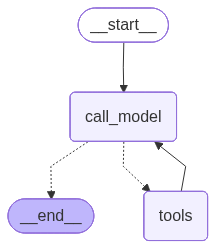

In [66]:
# 외부 서버를 호출하는 동안 대기시간 초과로 오류가 날 수 있습니다.
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

1. 처음 6개 대화 → END
2. 7번째 입력 → summarize_conversation 실행
    * 요약1 생성
    * 오래된 메시지 삭제
3. 또 6개 쌓이면 → 요약2 생성
    * 기존 요약 + 새 메시지로 “요약 이어 쓰기”
    * 다시 삭제

#### 4) 대화 시작

* 출력 함수 생성

| 부분 | 설명 |
| ---- | ---- |
| update | 그래프 노드 실행 후 변경된 상태 정보 |
| messages | LLM 대화 메시지 리스트 |
| summary | 누적된 요약 정보 (있으면 출력) |
| pretty_print() | 메시지를 보기 좋게 출력하는 LangChain 메서드 |


In [67]:
def print_update(update):
    for k, v in update.items():
        for m in v["messages"]:
            m.pretty_print()
        if "summary" in v:
            print(v["summary"])

In [68]:
config = {"configurable": {"thread_id": "10"}}
input_message = HumanMessage(content="안녕? 내 이름은 핑크퐁이야")
input_message.pretty_print()
for event in app.stream({"messages": [input_message]}, config, stream_mode="updates"):
    print_update(event)

input_message = HumanMessage(content="내이름이 뭐라고?")
input_message.pretty_print()
for event in app.stream({"messages": [input_message]}, config, stream_mode="updates"):
    print_update(event)

input_message = HumanMessage(content="나는 FC 바르셀로나를 좋아해!")
input_message.pretty_print()
for event in app.stream({"messages": [input_message]}, config, stream_mode="updates"):
    print_update(event)

================================ Human Message =================================

안녕? 내 이름은 핑크퐁이야
================================== Ai Message ==================================

안녕, 핑크퐁! 만나서 반가워. 어떻게 도와줄까?
================================ Human Message =================================

내이름이 뭐라고?
================================== Ai Message ==================================

네 이름은 핑크퐁이라고 했어! 맞아?
================================ Human Message =================================

나는 FC 바르셀로나를 좋아해!
================================== Ai Message ==================================

오, FC 바르셀로나를 좋아하는구나! 멋진 팀이지. 좋아하는 선수나 기억에 남는 경기가 있어?


In [69]:
# 지금까지 요약이 이루어지지 않음
# 목록에 메시지가 6개뿐이기 때문입니다.

values = app.get_state(config).values
values

{'messages': [HumanMessage(content='안녕? 내 이름은 핑크퐁이야', additional_kwargs={}, response_metadata={}, id='54a21d83-ea7c-46f3-ac6f-1b755badcd74'),
  AIMessage(content='안녕, 핑크퐁! 만나서 반가워. 어떻게 도와줄까?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 21, 'total_tokens': 43, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_4c2851f862', 'id': 'chatcmpl-CV90xh3JAgZu5fYQBXwNaCj6vIl44', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--c9257aca-593b-4728-9a77-4065e2c07402-0', usage_metadata={'input_tokens': 21, 'output_tokens': 22, 'total_tokens': 43, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}),
  HumanMessage(content='내이름

* 이제 한번 더 이야기하면, 과거 6개 메시지가 요약되고, 삭제 됩니다.

In [70]:
input_message = HumanMessage(content="나는 그들이 항상 이기는게 좋아.")
input_message.pretty_print()
for event in app.stream({"messages": [input_message]}, config, stream_mode="updates"):
    print_update(event)

================================ Human Message =================================

나는 그들이 항상 이기는게 좋아.
================================== Ai Message ==================================

바르셀로나가 항상 이기면 정말 기분 좋겠지! 멋진 경기를 많이 보여줘서 팬으로서 자랑스러울 것 같아. 혹시 좋아하는 시즌이나 기억에 남는 우승 순간이 있어?
================================ Remove Message ================================


================================ Remove Message ================================


================================ Remove Message ================================


================================ Remove Message ================================


================================ Remove Message ================================


================================ Remove Message ================================


물론이야! 지금까지 대화 내용을 요약해볼게.

- 너는 이름이 핑크퐁이라고 했어.
- FC 바르셀로나를 좋아한다고 말했어.
- 특히 바르셀로나가 항상 이기는 점이 좋다고 했어.

더 궁금한 거 있으면 언제든 말해줘!


In [71]:
values = app.get_state(config).values
values

{'messages': [HumanMessage(content='나는 그들이 항상 이기는게 좋아.', additional_kwargs={}, response_metadata={}, id='27467fc7-7f1c-4264-83d0-53a76a96e4ee'),
  AIMessage(content='바르셀로나가 항상 이기면 정말 기분 좋겠지! 멋진 경기를 많이 보여줘서 팬으로서 자랑스러울 것 같아. 혹시 좋아하는 시즌이나 기억에 남는 우승 순간이 있어?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 140, 'total_tokens': 193, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_4c2851f862', 'id': 'chatcmpl-CV918IK3mh7OLoA3nqwqhLzgwhbJW', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--0f086d35-e257-4423-a9a2-d0e2a15d19b9-0', usage_metadata={'input_tokens': 140, 'output_tokens': 53, 'total_tokens': 193, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_de

이제 대화를 계속할 수 있습니다! 마지막 두 개의 메시지만 있지만 대화에서 앞서 언급한 내용에 대해 여전히 질문할 수 있습니다(요약했기 때문입니다)

In [72]:
input_message = HumanMessage(content="참, 내 이름이 뭐라고?")
input_message.pretty_print()
for event in app.stream({"messages": [input_message]}, config, stream_mode="updates"):
    print_update(event)

================================ Human Message =================================

참, 내 이름이 뭐라고?
================================== Ai Message ==================================

너는 핑크퐁이라고 했어! 맞지? 기억하는 게 맞으면 언제든지 알려줘.


In [73]:
input_message = HumanMessage(content="내가 좋아하는 축구팀은?")
input_message.pretty_print()
for event in app.stream({"messages": [input_message]}, config, stream_mode="updates"):
    print_update(event)

================================ Human Message =================================

내가 좋아하는 축구팀은?
================================== Ai Message ==================================

네가 좋아하는 축구팀은 FC 바르셀로나야! 항상 이기는 점이 특히 좋다고 했지.


In [74]:
input_message = HumanMessage(content="우리팀과 경쟁하는 팀이 어디야?")
input_message.pretty_print()
for event in app.stream({"messages": [input_message]}, config, stream_mode="updates"):
    print_update(event)

================================ Human Message =================================

우리팀과 경쟁하는 팀이 어디야?
================================== Ai Message ==================================

바르셀로나의 주요 경쟁 팀으로는 레알 마드리드와 아틀레티코 마드리드가 있어. 특히 레알 마드리드와의 ‘엘 클라시코’ 경기는 전 세계 축구 팬들이 가장 기대하는 빅매치 중 하나야! 이 경기는 항상 뜨거운 경쟁과 멋진 경기로 유명하지.
================================ Remove Message ================================


================================ Remove Message ================================


================================ Remove Message ================================


================================ Remove Message ================================


================================ Remove Message ================================


================================ Remove Message ================================


- 바르셀로나와 경쟁하는 주요 팀으로 레알 마드리드와 아틀레티코 마드리드를 꼽았어.  
- 특히 레알 마드리드와의 ‘엘 클라시코’ 경기가 가장 치열하고 유명한 라이벌전이라는 점을 이야기했어.

더 궁금한 점이나 이야기하고 싶은 게 있으면 편하게 말해줘!


## 5.실습

### (1) 실습1
* 최근 메시지 n개만 기억 : 기억할 메세지 개수 제한하기
    * 기존 코드 수정하기
    * 포함사항 : 시스템 메시지(역할) 지정하기(chatbot 함수에 추가)
    * agent를 만들고 대화하면서 이전 메시지가 제외되는지 확인하기

* node 정의

In [ ]:
n = 2

In [76]:
llm = ChatOpenAI(model="gpt-4.1-mini")  # 언어 모델을 gpt-4.1-mini로 설정

def filter_messages(messages: list):
    # 최근 2개 메시지만 리턴하는 필터 함수 생성
    return messages[-n:]

def chatbot(state: State):
    messages = filter_messages(state["messages"])
    result = llm.invoke(messages)
    return {"messages": [result]}

* 그래프 정의

In [77]:
# initiate a graph
builder = StateGraph(State)

# add a node
builder.add_node("chatbot", chatbot)

# connect nodes
builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

# compile the graph
memory = MemorySaver()  # 메모리 기반 체크포인터 초기화
agent_with_memory = builder.compile(checkpointer=memory)

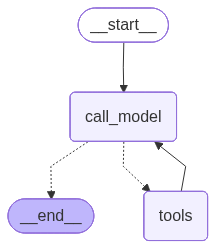

In [78]:
graph

In [79]:
thread_7 = {"configurable": {"thread_id": "7"}}
messages = [HumanMessage(content="3과 4를 더하라")]
messages = agent_with_memory.invoke({"messages": messages}, thread_7)
messages['messages'][-1].pretty_print()

messages = [HumanMessage(content="내 이름은 한기영이야.")]
messages = agent_with_memory.invoke({"messages": messages}, thread_7)
messages['messages'][-1].pretty_print()

messages = [HumanMessage(content="오늘 날씨 어때?")]
messages = agent_with_memory.invoke({"messages": messages}, thread_7)
messages['messages'][-1].pretty_print()

messages = [HumanMessage(content="아까 계산했던 값이 얼마?")]
messages = agent_with_memory.invoke({"messages": messages}, thread_7)
messages['messages'][-1].pretty_print()

================================== Ai Message ==================================

3과 4를 더하면 7입니다.
================================== Ai Message ==================================

반갑습니다, 한기영 님! 어떻게 도와드릴까요?
================================== Ai Message ==================================

현재 위치를 알려주시면 오늘 날씨를 알려드릴 수 있어요. 어느 지역의 날씨가 궁금하신가요?
================================== Ai Message ==================================

죄송하지만, 지금은 이전 대화 내용을 기억하지 못해요. 다시 계산해 드릴 내용을 알려주시면 바로 도와드릴게요!


### (2) [추가] 실습2
메시지 요약

위 실습1의 메모리를 요약 메모리로 변경해 봅시다.

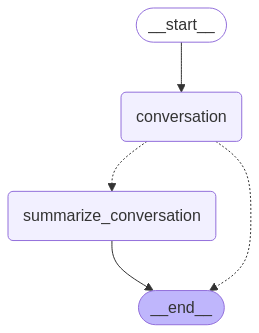

* 1) State
    * MessagesState는 LangGraph가 기본 제공하는 메시지 기반 상태
    * 여기에 **summary**라는 새로운 필드를 추가

In [80]:
class State(TypedDict):
    messages: Annotated[list, add_messages]
    summary: str

* 2) 노드와 분기함수

* **대화 노드**

    * 기존 메시지 리스트로 GPT를 호출해서 응답을 받고,
    * 그 응답을 메시지 리스트에 **누적시킬 준비**를 해줌

In [84]:
def conversation(state: State):
    summary = state.get("summary", "")
    if summary:
        # 요약을 system prompt로 넣어 대화 맥락 유지
        system_message = f"이전 대화 요약: {summary}"
        messages = [SystemMessage(content=system_message)] + state["messages"]
    else:
        messages = state["messages"]

    response = llm.invoke(messages)
    return {"messages": [response]}

* **분기 조건**
    * 메시지가 6개 초과하면 **summarize_conversation** 노드로 분기
    * 그렇지 않으면 바로 **END**

In [82]:
def should_continue(state: State) -> Literal["summarize_conversation", END]:
    if len(state["messages"]) > 6:
        return "summarize_conversation"
    return END

* **요약 노드**
    * 지금까지 대화 내용으로 요약 생성
    * 메시지 너무 많아지지 않도록 앞쪽 메시지 삭제
    * 요약은 state["summary"]에 저장됨 (누적 요약 느낌)

In [83]:
from langchain_core.messages import RemoveMessage

def summarize_conversation(state: State):
    summary = state.get("summary", "")   # 이전에 요약된게 있다면, 불러오고, 없으면 ""
    if summary:
        summary_message = (
            f"지금까지 요약된 내용 : {summary}\n\n"
            "여기에 새 메시지를 반영해서 요약하고 그 외의 답변은 하지마세요." )
    else:
        # 이전 요약이 없다면 (처음 요약) → 대화 전체를 요약해달라고 지시
        summary_message = "대화 내용을 요약하고 그 외의 답변은 하지마세요.:"

    # 기존 메시지 목록 끝에 요약 요청 프롬프트를 HumanMessage로 추가
    messages = state["messages"] + [HumanMessage(content=summary_message)]
    # 전체 메시지 + 요약 요청을 GPT에게 전달해서 요약 결과 받기
    response = llm.invoke(messages)

    # 오래된 메시지를 제거 → 최신 2개만 유지
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"summary": response.content, "messages": delete_messages}

* 3) 그래프 정의

In [87]:
workflow = StateGraph(State)
workflow.add_node("conversation", conversation)
workflow.add_node("summarize_conversation", summarize_conversation)

workflow.add_edge(START, "conversation")
workflow.add_edge("summarize_conversation", END)
workflow.add_conditional_edges("conversation", should_continue)

memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

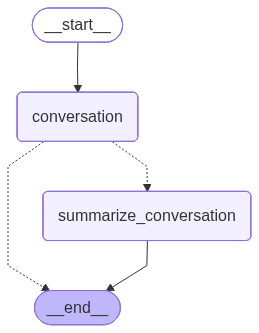

In [88]:
app

* 4) 대화 시작

* 출력 함수 생성

| 부분 | 설명 |
| ---- | ---- |
| update | 그래프 노드 실행 후 변경된 상태 정보 |
| messages | LLM 대화 메시지 리스트 |
| summary | 누적된 요약 정보 (있으면 출력) |
| pretty_print() | 메시지를 보기 좋게 출력하는 LangChain 메서드 |


In [89]:
def print_update(update):
    for k, v in update.items():
        for m in v["messages"]:
            m.pretty_print()
        if "summary" in v:
            print(v["summary"])

In [90]:
config = {"configurable": {"thread_id": "10"}}
input_message = HumanMessage(content="안녕? 내 이름은 핑크퐁이야")
input_message.pretty_print()
for event in app.stream({"messages": [input_message]}, config, stream_mode="updates"):
    print_update(event)

input_message = HumanMessage(content="내이름이 뭐라고?")
input_message.pretty_print()
for event in app.stream({"messages": [input_message]}, config, stream_mode="updates"):
    print_update(event)

input_message = HumanMessage(content="나는 FC 바르셀로나를 좋아해!")
input_message.pretty_print()
for event in app.stream({"messages": [input_message]}, config, stream_mode="updates"):
    print_update(event)

================================ Human Message =================================

안녕? 내 이름은 핑크퐁이야
================================== Ai Message ==================================

안녕, 핑크퐁! 만나서 반가워. 어떻게 도와줄까?
================================ Human Message =================================

내이름이 뭐라고?
================================== Ai Message ==================================

네 이름은 핑크퐁이라고 했어! 맞지?
================================ Human Message =================================

나는 FC 바르셀로나를 좋아해!
================================== Ai Message ==================================

와, FC 바르셀로나를 좋아하는구나! 멋진 팀이지! 좋아하는 선수나 경기 있어?


* 이제 한번 더 이야기하면, 과거 6개 메시지가 요약되고, 삭제 됩니다.

In [91]:
input_message = HumanMessage(content="나는 그들이 항상 이기는게 좋아.")
input_message.pretty_print()
for event in app.stream({"messages": [input_message]}, config, stream_mode="updates"):
    print_update(event)

================================ Human Message =================================

나는 그들이 항상 이기는게 좋아.
================================== Ai Message ==================================

그렇구나! FC 바르셀로나는 정말 강한 팀이라 멋진 경기를 많이 보여주지. 앞으로도 좋아하는 팀이 좋은 성적 거두길 바랄게! 혹시 바르셀로나에 대해 더 이야기하고 싶은 거 있어?
================================ Remove Message ================================


================================ Remove Message ================================


================================ Remove Message ================================


================================ Remove Message ================================


================================ Remove Message ================================


================================ Remove Message ================================


사용자 이름은 핑크퐁이며, FC 바르셀로나를 좋아하고 그들이 항상 이기는 것을 좋아한다고 말했다.


이제 대화를 계속할 수 있습니다! 마지막 두 개의 메시지만 있지만 대화에서 앞서 언급한 내용에 대해 여전히 질문할 수 있습니다(요약했기 때문입니다)

## 6.체크포인트 저장소(Checkpoint Store)

SQLite DB

**구성**
- checkpoints.sqlite
    - 메인 데이터베이스 파일
    - 모든 데이터의 기본 저장소
- checkpoints.sqlite-wal
    - 쓰기 로그(Write-Ahead Log)
    - 최신 변경사항이 일시적으로 저장됨
- checkpoints.sqlite-shm
    - 공유 메모리 파일 (Shared Memory)



In [93]:
!pip install langgraph-checkpoint-sqlite -q

In [94]:
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver

### (1) DB 생성 및 연결

In [95]:
# check_same_thread=False - 여러 스레드에서 같은 연결 객체를 공유할 수 있도록 허용
# LangGraph나 LangChain은 비동기 처리 또는 멀티 스레드 실행을 사용하는 경우가 많아.

sqlite3_conn = sqlite3.connect('checkpoints.sqlite',check_same_thread=False)
sqlite3_memory_checkpoint = SqliteSaver(sqlite3_conn)

### (2) 메모리 지정

In [97]:
graph = builder.compile(checkpointer=sqlite3_memory_checkpoint)

### (3) 대화

In [98]:
graph.invoke(
    {"messages": [HumanMessage("안녕?")]},
    config={"configurable": {"thread_id": 1}}
)

{'messages': [HumanMessage(content='안녕?', additional_kwargs={}, response_metadata={}, id='0ea19a4b-88b2-4a0b-98f0-330bd2bdefa4'),
  AIMessage(content='안녕하세요! 무엇을 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 10, 'total_tokens': 21, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_4c2851f862', 'id': 'chatcmpl-CV9nuri1hl4mUiqHwFa5DX7LzpnBc', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--435a79af-f3f7-4fa8-aec1-3b7b2da219b8-0', usage_metadata={'input_tokens': 10, 'output_tokens': 11, 'total_tokens': 21, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}

In [99]:
graph.invoke(
    {"messages": [HumanMessage("내이름은 한기영")]},
    config={"configurable": {"thread_id": 1}}
)

{'messages': [HumanMessage(content='안녕?', additional_kwargs={}, response_metadata={}, id='0ea19a4b-88b2-4a0b-98f0-330bd2bdefa4'),
  AIMessage(content='안녕하세요! 무엇을 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 10, 'total_tokens': 21, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_4c2851f862', 'id': 'chatcmpl-CV9nuri1hl4mUiqHwFa5DX7LzpnBc', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--435a79af-f3f7-4fa8-aec1-3b7b2da219b8-0', usage_metadata={'input_tokens': 10, 'output_tokens': 11, 'total_tokens': 21, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}),
  HumanMessage(content='내이름은 한기영', additional_kw